#### FPVS pypeline 2 pynt 0
This is the second edition of the FPVS pypeline where all processes/steps in the pipeline are functionalized so that they can be completed in a more streamlined manner in addition to this application being distributed as a package. 
steps 

1. Preprocess step 1

## Import libraries

In [1]:
%reset -f
import cust_funcs as cf
import FPVS_pycage as FPVS
from pathlib import Path
import importlib
import scipy.io as sci
import numpy as np
# importlib.reload(FPVS)

## Preprocessing phase 1 
0. Remodelling the lw6 and mat data to make them more Python-friendly
1. Rename channels
2. Changing the channel locations and adding spherical coordinates to the meta (lw6) data
3. Downsampling the mat_data 
4. Deleting the EXG X and status channels
5. Bandpass and notch filtering

In [ ]:
importlib.reload(cf)
importlib.reload(FPVS)
matfilepath = Path("D:\Goffaux lab\Data set\Python files\BEFR2711.mat")
lw6filepath = matfilepath.with_suffix(".lw6")
subjid = matfilepath.stem
mat_data, meta_data , metafilepath = FPVS.preprocessFPVSdata_phase1(matfilepath,lw6filepath)

In [ ]:
meta_data["chanlocs"]["labels"]
meta_data["chanlocs"][0][0]["labels"]


## Performing ICA 
Because jupyter is asynchronous, i have to split the perform_ICA, overlay ICA and apply ICA separately, in three different cells. 

In [ ]:
print(metafilepath)

In [ ]:
importlib.reload(FPVS)
matfilepath = metafilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')

print(metafilepath.exists())
print(metafilepath)
print(matfilepath)
ica, raw, ica_data, idx = FPVS.preprocessFPVSdata_performICA(matfilepath=matfilepath, metafilepath = metafilepath)

## Overlay ICA data on actual activation

In [ ]:
importlib.reload(FPVS)
FPVS.overlayICAondata(matfilepath,metafilepath,ica_data)

## Apply ICA to the actual data. 

In [ ]:
## rmidx is the variable where the Independent components with blink are stored and will be removed in the next cell
# rmidx = [0,2,3,7,8,9,10,12] #ADVI
rmidx = [0,2,3,5,6,9,11,13,15,16,17,18,19,20,21,23,24] # 24 looks dicey CHMA


In [ ]:
importlib.reload(cf)
importlib.reload(FPVS)
mat_data, meta_data, metafilepath = FPVS.preprocessFPVSdata_applyICA(matfilepath, metafilepath, ica , raw, rmidx)

## Interpolate channels

In [ ]:
matfilepath = metafilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')
print(matfilepath)
mat_data = np.load(matfilepath)
meta_data = cf.loadMetadata(metafilepath)
cf.showmeSignalUI(mat_data, meta_data,ylim=150)

In [ ]:
interp_chnames = ['P1','P3','PO3']
bad_chids = ['Fp1','CP6','I2']
print(labels)

In [ ]:
importlib.reload(FPVS)
mat_data,meta_data,metafile = FPVS.preprocessFPVSdata_phase2(matfilepath,metafilepath,interp_chnames=interp_chnames,bad_but_ignore=bad_chids)

## Segmenting the data 

In [ ]:
importlib.reload(cf)
importlib.reload(FPVS)
print(metafilepath)
metafilepath = metafilepath.with_suffix('.pkl')
matfilepath = metafilepath.with_suffix('.npy')
mat_data, meta_data, metafilepath = FPVS.preprocesssFPVSdata_segmentation(matfilepath, metafilepath)

## Sanity checks

In [ ]:
import numpy as np
importlib.reload(cf)
matfilepath = metafilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')
mat_data = np.load(matfilepath)
meta_data = cf.loadMetadata(metafilepath)

fs = meta_data['fs']
chid = 26
subjid = matfilepath.stem.split()[-1]
epochid = 27
signal = mat_data[:,chid,epochid]
label = meta_data["chanlocs"]["labels"][chid]
cf.showmeSummaryPlot(signal = signal, fs = fs, chname = label, subjid = subjid,epochid = epochid,freqlim = [0, 12])

In [ ]:
print(meta_data['chanlocs']['labels'])
print(mat_data.shape)

In [ ]:
import numpy as np
for key in meta_data["chanlocs"].keys():
    print(key," has the shape: ", np.shape(meta_data["chanlocs"][key]))

print(odd_data.shape)

## Post processing 
1. FFT transform
2. averaging within trials
3. Frequency window chunking
4. Chunk selection( and splitting based on baseline and oddball chunks)
5. Sum of chunks/harmonics
6. baseline correction (I havent done SNR correction yet)

In [ ]:
importlib.reload(FPVS)
event_label = "200"
folderPath = Path("D:\Goffaux lab\Data set\Python files")
odd_data, bl_data, oddfilepath, blfilepath = FPVS.postprocessFPVSdata(event_label, folderPath.parent)

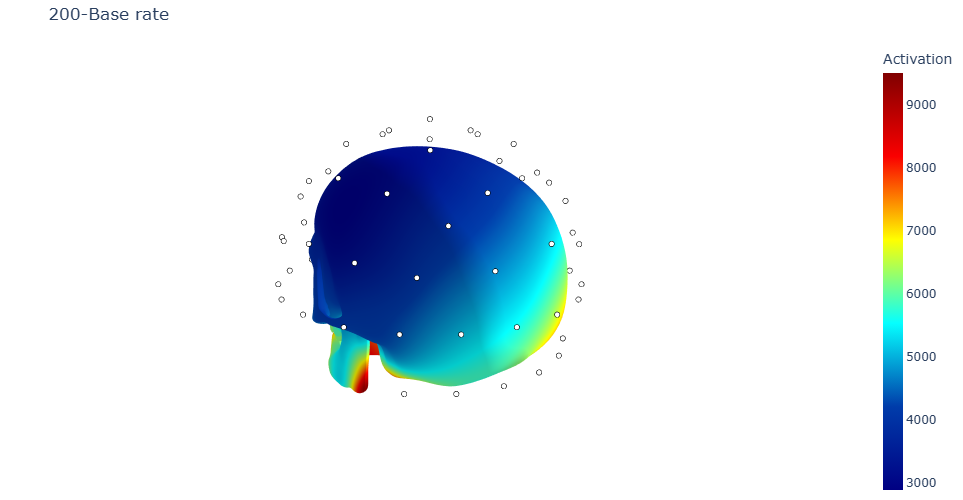

In [2]:
event_label = "200"
importlib.reload(FPVS)
importlib.reload(cf)
metafilepath = Path("D:\Goffaux lab\Data set\Python files\split 8_ref 7_ep 6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.pkl")
blfilepath = Path("D:\Goffaux lab\Data set\Python files\\14_sum 13_baseline 12_chunk 11_avg 10_FFT 200 MERGED.npy")
bl_data = np.load(blfilepath)
meta_data = cf.loadMetadata(metafilepath)
# print(bl_data.shape)
titlestr = f"{event_label}-Base rate"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],meta_data)
cf.showme3DTopomap(bl_data[freqid,:],meta_data,titlestr)

In [ ]:
cf.showmeSignal(bl_data)

In [ ]:
importlib.reload(cf)
cf.showme2DTopomap(bl_data[freqid,:],meta_data,titlestr)

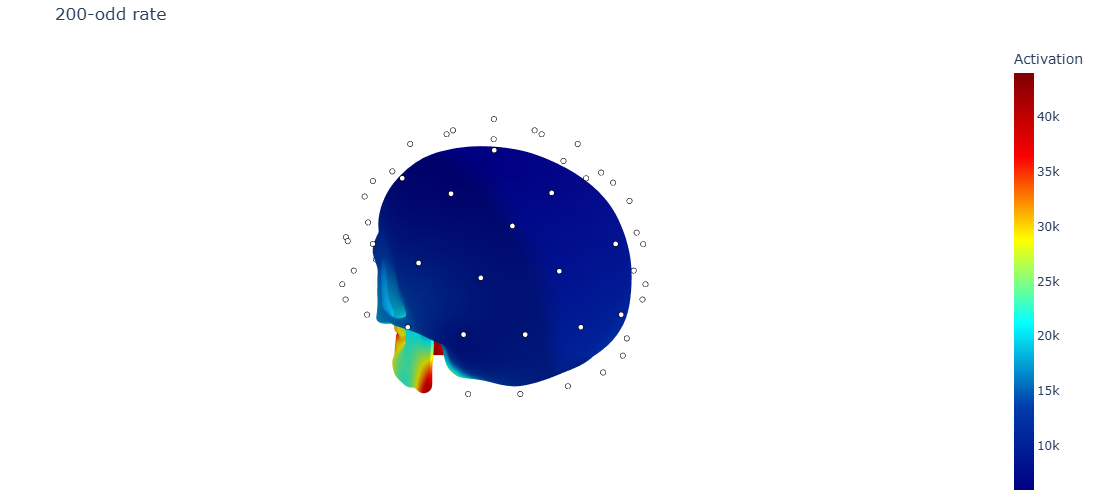

In [3]:
importlib.reload(cf)
metafilepath = Path("D:\Goffaux lab\Data set\Python files\split 8_ref 7_ep 6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.pkl")
oddfilepath = Path("D:\Goffaux lab\Data set\Python files\\14_sum 13_oddball 12_chunk 11_avg 10_FFT 200 MERGED.npy")
odd_data = np.load(oddfilepath)
meta_data = cf.loadMetadata(metafilepath)
# print(bl_data.shape)
titlestr_odd = f"{event_label}-odd rate"
%matplotlib widget
freqid = odd_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],meta_data)
cf.showme3DTopomap(odd_data[freqid,:],meta_data,titlestr_odd)


In [ ]:
cf.showmeSignal(odd_data)

In [ ]:
importlib.reload(cf)
cf.showme2DTopomap(odd_data[freqid,:],meta_data,titlestr_odd)

In [2]:
pip install --upgrade trimesh


  Using cached trimesh-4.12.2-py3-none-any.whl.metadata (13 kB)
Using cached trimesh-4.12.2-py3-none-any.whl (741 kB)
  Attempting uninstall: trimesh
    Found existing installation: trimesh 4.12.1
    Uninstalling trimesh-4.12.1:
      Successfully uninstalled trimesh-4.12.1
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import trimesh 
mesh = trimesh.load('closed head.obj')
print(mesh)
# vertices = mesh.vertices.copy()
# print(mesh.faces)

SyntaxError: invalid syntax (581768842.py, line 1)

In [4]:
importlib.reload(cf)
cf.showme3DTopomapnewmesh(bl_data[freqid,:],meta_data,titlestr)

ValueError: operands could not be broadcast together with shapes (4,4) (3,3) 